# Wafer Anomaly Detection with PatchCore + EfficientNet-B0 (50k Train Normals)

This notebook trains a PatchCore-style anomaly detector on **50,000 normal wafers** and tests on:
- **5,000 normal** wafers
- **250 defect** wafers

Pipeline:
1. Load and clean WM-811K style wafer data
2. Convert wafer maps to 3-channel tensors
3. Extract multi-scale patch embeddings from a pretrained CNN
4. Build PatchCore memory bank from train-normal patches
5. Score test images by nearest-neighbor patch distance
6. Evaluate with ROC-AUC, confusion matrix, and classification report

In [14]:
# Core imports
import os
import gc
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

print('Using device:', DEVICE)

Using device: cuda


In [ ]:
# Configuration
DATA_PATH = '../data/raw/LSWMD.pkl'
IMAGE_SIZE = 224

NUM_WORKERS = 0
PIN_MEMORY = False
PERSISTENT_WORKERS = False
PREFETCH_FACTOR = None
BATCH_SIZE = 128 if USE_CUDA else 64

TRAIN_NORMAL_N = 20000
TUNE_NORMAL_N = 2500
TUNE_DEFECT_N = 2500
TEST_NORMAL_N = 5000
TEST_DEFECT_N = 250

# PatchCore memory/scoring settings
MEMORY_BANK_MAX_PATCHES = 240000 if USE_CUDA else 80000
SCORE_CHUNK = 1024 if USE_CUDA else 512
PATCHCORE_NN_K = 3
TOPK_PATCH_RATIO = 0.03
EFFNET_MID_FEATURE_IDX = 3
EFFNET_DEEP_FEATURE_IDX = 8
PATCH_EMBED_DIM = 512
USE_AMP = USE_CUDA

# Threshold sweep settings
THRESHOLD_PERCENTILE_MIN = 95.0
THRESHOLD_PERCENTILE_MAX = 99.9
THRESHOLD_PERCENTILE_STEPS = 40
THRESHOLD_GRID_STEPS = 120

# Artifact output
ARTIFACT_DIR = '../artifacts/x64/patchcore_efficientnet_b0_50k'
MODEL_EXPORT_PATH = os.path.join(ARTIFACT_DIR, 'patchcore_efficientnet_b0_model.pt')
METRICS_EXPORT_PATH = os.path.join(ARTIFACT_DIR, 'evaluation_metrics.json')
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(
    f'workers={NUM_WORKERS}, batch={BATCH_SIZE}, '
    f'pin={PIN_MEMORY}, bank_max={MEMORY_BANK_MAX_PATCHES}, '
    f'chunk={SCORE_CHUNK}, amp={USE_AMP}, topk_ratio={TOPK_PATCH_RATIO}, '
    f'nn_k={PATCHCORE_NN_K}, eff_mid={EFFNET_MID_FEATURE_IDX}, '
    f'eff_deep={EFFNET_DEEP_FEATURE_IDX}, emb_dim={PATCH_EMBED_DIM}'
)
print(
    f'threshold sweep: pct[{THRESHOLD_PERCENTILE_MIN}, {THRESHOLD_PERCENTILE_MAX}] '
    f'steps={THRESHOLD_PERCENTILE_STEPS}, grid_steps={THRESHOLD_GRID_STEPS}'
)
print('Artifacts will be saved to:', ARTIFACT_DIR)

workers=0, batch=128, pin=False, bank_max=240000, chunk=1024, amp=True, topk_ratio=0.03, nn_k=3, eff_mid=3, eff_deep=7, emb_dim=512
threshold sweep: pct[95.0, 99.9] steps=40, grid_steps=120
Artifacts will be saved to: ../artifacts/x64/patchcore_efficientnet_b0_50k


In [16]:
# Load and clean labels
df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(value):
    if value is None:
        return 'unknown'
    if isinstance(value, float) and np.isnan(value):
        return 'unknown'
    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.array(value).reshape(-1)
        if len(arr) == 0:
            return 'unknown'
        return str(arr[0])
    return str(value)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).astype(str).str.strip()
invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

print('Labeled shape:', df.shape)
print('Normal wafers:', len(normal_df))
print('Defect wafers:', len(defect_df))

Raw shape: (811457, 6)
Labeled shape: (172950, 8)
Normal wafers: 147431
Defect wafers: 25519


In [17]:
# Enforce requested split sizes with tune split
required_normals = TRAIN_NORMAL_N + TUNE_NORMAL_N + TEST_NORMAL_N
required_defects = TUNE_DEFECT_N + TEST_DEFECT_N

if len(normal_df) < required_normals:
    raise ValueError(f'Not enough normal wafers: need {required_normals}, found {len(normal_df)}')
if len(defect_df) < required_defects:
    raise ValueError(f'Not enough defect wafers: need {required_defects}, found {len(defect_df)}')

rng = np.random.default_rng(SEED)
normal_idx = rng.permutation(len(normal_df))
defect_idx = rng.permutation(len(defect_df))

normal_df_shuf = normal_df.iloc[normal_idx].reset_index(drop=True)
defect_df_shuf = defect_df.iloc[defect_idx].reset_index(drop=True)

n0 = 0
n1 = TRAIN_NORMAL_N
n2 = TRAIN_NORMAL_N + TUNE_NORMAL_N
n3 = TRAIN_NORMAL_N + TUNE_NORMAL_N + TEST_NORMAL_N

train_normal_df = normal_df_shuf.iloc[n0:n1].copy()
tune_normal_df = normal_df_shuf.iloc[n1:n2].copy()
test_normal_df = normal_df_shuf.iloc[n2:n3].copy()

d0 = 0
d1 = TUNE_DEFECT_N
d2 = TUNE_DEFECT_N + TEST_DEFECT_N

tune_defect_df = defect_df_shuf.iloc[d0:d1].copy()
test_defect_df = defect_df_shuf.iloc[d1:d2].copy()

print('Train normal:', len(train_normal_df))
print('Tune normal:', len(tune_normal_df))
print('Tune defect:', len(tune_defect_df))
print('Test normal:', len(test_normal_df))
print('Test defect:', len(test_defect_df))

Train normal: 20000
Tune normal: 2500
Tune defect: 2500
Test normal: 5000
Test defect: 250


In [18]:
# Wafer map -> 3ch tensor
def wafer_to_tensor(wafer_map, size=224):
    arr = np.array(wafer_map, dtype=np.int64)
    arr = np.clip(arr, 0, 2)
    x = torch.tensor(arr, dtype=torch.long)
    x = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()
    x = x.unsqueeze(0)
    x = F.interpolate(x, size=(size, size), mode='nearest')
    return x.squeeze(0)

def build_tensor(frame, size=224):
    imgs = [wafer_to_tensor(w, size=size) for w in frame['waferMap'].values]
    X = torch.stack(imgs)
    y = torch.tensor(frame['is_anomaly'].values, dtype=torch.long)
    return X, y

X_train, y_train = build_tensor(train_normal_df, IMAGE_SIZE)
X_tune_normal, y_tune_normal = build_tensor(tune_normal_df, IMAGE_SIZE)
X_tune_defect, y_tune_defect = build_tensor(tune_defect_df, IMAGE_SIZE)
X_test_normal, y_test_normal = build_tensor(test_normal_df, IMAGE_SIZE)
X_test_defect, y_test_defect = build_tensor(test_defect_df, IMAGE_SIZE)

print('X_train:', tuple(X_train.shape))
print('X_tune_normal:', tuple(X_tune_normal.shape))
print('X_tune_defect:', tuple(X_tune_defect.shape))
print('X_test_normal:', tuple(X_test_normal.shape))
print('X_test_defect:', tuple(X_test_defect.shape))

X_train: (20000, 3, 224, 224)
X_tune_normal: (2500, 3, 224, 224)
X_tune_defect: (2500, 3, 224, 224)
X_test_normal: (5000, 3, 224, 224)
X_test_defect: (250, 3, 224, 224)


In [19]:
# DataLoaders
loader_kwargs = {
    'batch_size': BATCH_SIZE,
    'shuffle': False,
    'num_workers': NUM_WORKERS,
    'pin_memory': PIN_MEMORY,
}
if NUM_WORKERS > 0:
    loader_kwargs['persistent_workers'] = PERSISTENT_WORKERS
    loader_kwargs['prefetch_factor'] = PREFETCH_FACTOR

train_loader = DataLoader(TensorDataset(X_train, y_train), **loader_kwargs)
tune_normal_loader = DataLoader(TensorDataset(X_tune_normal, y_tune_normal), **loader_kwargs)
tune_defect_loader = DataLoader(TensorDataset(X_tune_defect, y_tune_defect), **loader_kwargs)
test_normal_loader = DataLoader(TensorDataset(X_test_normal, y_test_normal), **loader_kwargs)
test_defect_loader = DataLoader(TensorDataset(X_test_defect, y_test_defect), **loader_kwargs)

print('Train batches:', len(train_loader))
print('Tune normal batches:', len(tune_normal_loader))
print('Tune defect batches:', len(tune_defect_loader))
print('Test normal batches:', len(test_normal_loader))
print('Test defect batches:', len(test_defect_loader))

Train batches: 157
Tune normal batches: 20
Tune defect batches: 20
Test normal batches: 40
Test defect batches: 2


In [20]:
# PatchCore feature extractor from pretrained EfficientNet-B0
class PatchFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.features = backbone.features
        self.mid_idx = EFFNET_MID_FEATURE_IDX
        self.deep_idx = EFFNET_DEEP_FEATURE_IDX
        self.project_dim = PATCH_EMBED_DIM
        with torch.inference_mode():
            dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
            x = dummy
            f_mid = None
            f_deep = None
            for i, block in enumerate(self.features):
                x = block(x)
                if i == self.mid_idx:
                    f_mid = x
                if i == self.deep_idx:
                    f_deep = x
        if f_mid is None or f_deep is None:
            raise ValueError(f'Invalid EfficientNet feature indices: mid={self.mid_idx}, deep={self.deep_idx}')
        in_dim = f_mid.shape[1] + f_deep.shape[1]
        self.proj = nn.Linear(in_dim, self.project_dim, bias=False)

    def forward(self, x):
        f_mid = None
        f_deep = None
        for i, block in enumerate(self.features):
            x = block(x)
            if i == self.mid_idx:
                f_mid = x
            if i == self.deep_idx:
                f_deep = x
        if f_mid is None or f_deep is None:
            raise RuntimeError(f'Failed to collect EfficientNet feature maps at indices {self.mid_idx} and {self.deep_idx}.')
        return f_mid, f_deep

extractor = PatchFeatureExtractor().to(DEVICE).eval()
for p in extractor.parameters():
    p.requires_grad = False

def patch_embeddings(xb):
    with torch.inference_mode():
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP):
            f2, f3 = extractor(xb)
            f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
            emb = torch.cat([f2, f3_up], dim=1)
            emb = emb.permute(0, 2, 3, 1).reshape(-1, emb.size(1))
            emb = extractor.proj(emb)
        emb = F.normalize(emb.float(), p=2, dim=1)
    return emb

In [21]:
# Build memory bank from train-normal patches — keep tensors on GPU to avoid PCIe round-trips
sampled_patches = []
estimated_total_patches = None
total_seen_patches = 0
sample_ratio = 1.0

with torch.inference_mode():
    for xb, _ in train_loader:
        xb = xb.to(DEVICE, non_blocking=PIN_MEMORY)
        emb = patch_embeddings(xb)           # stays on GPU (no .cpu())
        total_seen_patches += len(emb)

        if estimated_total_patches is None:
            patches_per_image = len(emb) // len(xb)
            estimated_total_patches = patches_per_image * len(train_normal_df)
            sample_ratio = min(1.0, MEMORY_BANK_MAX_PATCHES / estimated_total_patches)
            print('Estimated raw memory bank patches:', estimated_total_patches)
            print('Sampling ratio:', round(sample_ratio, 6))

        if sample_ratio < 1.0:
            keep_n = max(1, int(round(len(emb) * sample_ratio)))
            keep_idx = torch.randperm(len(emb), device=DEVICE)[:keep_n]  # randperm on GPU
            emb = emb[keep_idx]

        sampled_patches.append(emb)          # GPU tensor

memory_bank = torch.cat(sampled_patches, dim=0)    # already on GPU
print('Sampled memory bank patches before trim:', len(memory_bank))
print('Observed raw patches during pass:', total_seen_patches)

if len(memory_bank) > MEMORY_BANK_MAX_PATCHES:
    keep_idx = torch.randperm(len(memory_bank), device=DEVICE)[:MEMORY_BANK_MAX_PATCHES]
    memory_bank = memory_bank[keep_idx]

memory_bank = F.normalize(memory_bank, p=2, dim=1).contiguous()   # no .to(DEVICE) needed
memory_bank_t = memory_bank.t().contiguous()
print('Final memory bank patches:', len(memory_bank), '| Emb dim:', memory_bank.shape[1])
print('Memory bank device:', memory_bank.device)

Estimated raw memory bank patches: 15680000
Sampling ratio: 0.015306
Sampled memory bank patches before trim: 240000
Observed raw patches during pass: 15680000
Final memory bank patches: 240000 | Emb dim: 512
Memory bank device: cuda:0


In [22]:
# PatchCore scoring with robust aggregation
# - Patch score: average distance to k nearest memory-bank neighbors
# - Image score: mean of top-k% most anomalous patch scores

def min_dist_to_bank(patches, bank_t, chunk=1024, nn_k=3):
    # Embeddings are L2-normalized, so Euclidean distance is derived from cosine similarity.
    mins = []
    for i in range(0, len(patches), chunk):
        p = patches[i:i + chunk]
        sim = p @ bank_t
        k = min(nn_k, sim.shape[1])
        best_sim = sim.topk(k=k, dim=1).values
        dist = torch.sqrt(torch.clamp(2.0 - 2.0 * best_sim, min=0.0))
        mins.append(dist.mean(dim=1))
    return torch.cat(mins, dim=0)

def score_loader(loader, bank_t, topk_patch_ratio=0.02, nn_k=3):
    img_scores = []
    with torch.inference_mode():
        for xb, _ in loader:
            xb = xb.to(DEVICE, non_blocking=PIN_MEMORY)
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP):
                f2, f3 = extractor(xb)
                f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
                emb = torch.cat([f2, f3_up], dim=1)
                emb = emb.permute(0, 2, 3, 1)
                b, h, w, c = emb.shape
                emb = emb.reshape(-1, c)
                emb = extractor.proj(emb)
            emb = F.normalize(emb.float(), p=2, dim=1)

            patch_scores = min_dist_to_bank(emb, bank_t, chunk=SCORE_CHUNK, nn_k=nn_k)
            patch_scores = patch_scores.reshape(b, h * w)
            topk_patches = max(1, int(round(patch_scores.shape[1] * topk_patch_ratio)))
            topk_patches = min(topk_patches, patch_scores.shape[1])
            score = patch_scores.topk(k=topk_patches, dim=1).values.mean(dim=1)
            img_scores.append(score.cpu())

    return torch.cat(img_scores).numpy()

train_scores = score_loader(
    train_loader,
    memory_bank_t,
    topk_patch_ratio=TOPK_PATCH_RATIO,
    nn_k=PATCHCORE_NN_K,
)
tune_normal_scores = score_loader(
    tune_normal_loader,
    memory_bank_t,
    topk_patch_ratio=TOPK_PATCH_RATIO,
    nn_k=PATCHCORE_NN_K,
)
tune_defect_scores = score_loader(
    tune_defect_loader,
    memory_bank_t,
    topk_patch_ratio=TOPK_PATCH_RATIO,
    nn_k=PATCHCORE_NN_K,
)
test_normal_scores = score_loader(
    test_normal_loader,
    memory_bank_t,
    topk_patch_ratio=TOPK_PATCH_RATIO,
    nn_k=PATCHCORE_NN_K,
)
test_defect_scores = score_loader(
    test_defect_loader,
    memory_bank_t,
    topk_patch_ratio=TOPK_PATCH_RATIO,
    nn_k=PATCHCORE_NN_K,
)

# Standardize scores using train-normal distribution for stable thresholding.
train_score_mu = float(np.mean(train_scores))
train_score_std = float(np.std(train_scores) + 1e-8)

train_scores_z = (train_scores - train_score_mu) / train_score_std
tune_normal_scores_z = (tune_normal_scores - train_score_mu) / train_score_std
tune_defect_scores_z = (tune_defect_scores - train_score_mu) / train_score_std
test_normal_scores_z = (test_normal_scores - train_score_mu) / train_score_std
test_defect_scores_z = (test_defect_scores - train_score_mu) / train_score_std
#save results for threshold tuning and final evaluation
np.savez_compressed(
    os.path.join(ARTIFACT_DIR, 'scores.npz'),
    train_scores_z=train_scores_z,
    tune_normal_scores_z=tune_normal_scores_z,
    tune_defect_scores_z=tune_defect_scores_z,
    test_normal_scores_z=test_normal_scores_z,
    test_defect_scores_z=test_defect_scores_z,
)

print(f'PatchCore scoring config -> nn_k={PATCHCORE_NN_K}, topk_patch_ratio={TOPK_PATCH_RATIO:.4f}')
print(f'Train normal score normalization -> mu={train_score_mu:.6f}, std={train_score_std:.6f}')

PatchCore scoring config -> nn_k=3, topk_patch_ratio=0.0300
Train normal score normalization -> mu=0.426556, std=0.032740


Tuned z-threshold: 0.953849 (raw score threshold: 0.457785)
Precision=0.8761 | Recall=0.8284 | F1=0.8516 | Balanced Acc=0.8556


,threshold_z,precision,recall,f1,specificity,balanced_accuracy,fp,fn
0,0.953849,0.876058,0.8284,0.851562,0.8828,0.8556,293,429
1,1.153862,0.900272,0.7944,0.844029,0.9120,0.8532,220,514
2,0.753836,0.838435,0.8656,0.851801,0.8332,0.8494,417,336
3,1.353874,0.918217,0.7500,0.825627,0.9332,0.8416,167,625
4,0.553824,0.797446,0.8992,0.845272,0.7716,0.8354,571,252
5,1.505453,0.929267,0.7252,0.814648,0.9448,0.8350,138,687
6,1.517615,0.930591,0.7240,0.814398,0.9460,0.8350,135,690
7,1.544844,0.931712,0.7204,0.812542,0.9472,0.8338,132,699
8,1.553887,0.931464,0.7176,0.810664,0.9472,0.8324,132,706
9,1.566425,0.931250,0.7152,0.809050,0.9472,0.8312,132,712


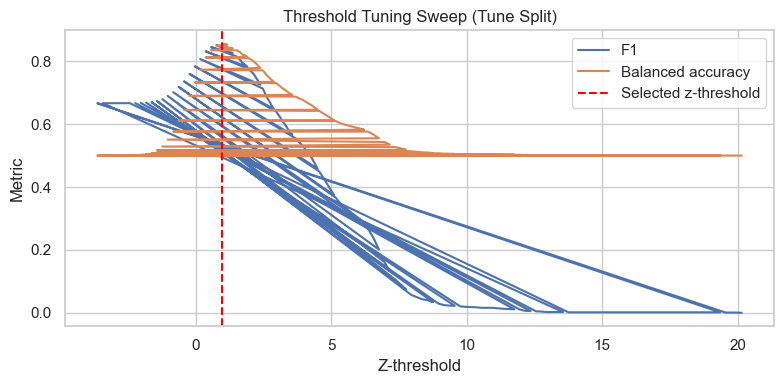

Run the next evaluation cell to report final test metrics with the tuned threshold.


In [23]:
#get from save results for threshold tuning and final evaluation
with np.load(os.path.join(ARTIFACT_DIR, 'scores.npz')) as data:
    train_scores_z = data['train_scores_z']
    tune_normal_scores_z = data['tune_normal_scores_z']
    tune_defect_scores_z = data['tune_defect_scores_z']
    test_normal_scores_z = data['test_normal_scores_z']
    test_defect_scores_z = data['test_defect_scores_z']

# Tune threshold on the labeled tune split (not on test)
y_tune = np.concatenate([
    np.zeros(len(tune_normal_scores_z), dtype=int),
    np.ones(len(tune_defect_scores_z), dtype=int),
])
score_tune = np.concatenate([tune_normal_scores_z, tune_defect_scores_z])

candidate_thresholds = np.unique(
    np.concatenate([
        np.percentile(train_scores_z, np.linspace(THRESHOLD_PERCENTILE_MIN, THRESHOLD_PERCENTILE_MAX, THRESHOLD_PERCENTILE_STEPS)),
        np.linspace(score_tune.min(), score_tune.max(), THRESHOLD_GRID_STEPS),
    ])
)

rows = []
for candidate in candidate_thresholds:
    pred = (score_tune > candidate).astype(int)
    tp = int(((pred == 1) & (y_tune == 1)).sum())
    tn = int(((pred == 0) & (y_tune == 0)).sum())
    fp = int(((pred == 1) & (y_tune == 0)).sum())
    fn = int(((pred == 0) & (y_tune == 1)).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    balanced_accuracy = 0.5 * (recall + specificity)

    rows.append({
        'threshold_z': float(candidate),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'specificity': specificity,
        'balanced_accuracy': balanced_accuracy,
        'fp': fp,
        'fn': fn,
    })

threshold_tuning = pd.DataFrame(rows).sort_values(
    ['balanced_accuracy', 'f1', 'precision', 'threshold_z'],
    ascending=[False, False, False, True],
).reset_index(drop=True)

best_row = threshold_tuning.iloc[0]
threshold_z = float(best_row['threshold_z'])
threshold_raw = train_score_mu + threshold_z * train_score_std

print(f"Tuned z-threshold: {threshold_z:.6f} (raw score threshold: {threshold_raw:.6f})")
print(
    f"Precision={best_row['precision']:.4f} | Recall={best_row['recall']:.4f} | "
    f"F1={best_row['f1']:.4f} | Balanced Acc={best_row['balanced_accuracy']:.4f}"
)
display(threshold_tuning.head(10))

plt.figure(figsize=(8, 4))
plt.plot(threshold_tuning['threshold_z'], threshold_tuning['f1'], label='F1')
plt.plot(threshold_tuning['threshold_z'], threshold_tuning['balanced_accuracy'], label='Balanced accuracy')
plt.axvline(threshold_z, color='red', linestyle='--', label='Selected z-threshold')
plt.xlabel('Z-threshold')
plt.ylabel('Metric')
plt.title('Threshold Tuning Sweep (Tune Split)')
plt.legend()
plt.tight_layout()
plt.show()

print('Run the next evaluation cell to report final test metrics with the tuned threshold.')

ROC-AUC (z-score): 0.9337
Applied z-threshold: 0.953849 | raw-threshold: 0.457785
              precision    recall  f1-score   support

      normal       0.99      0.88      0.94      5000
     anomaly       0.27      0.86      0.41       250

    accuracy                           0.88      5250
   macro avg       0.63      0.87      0.67      5250
weighted avg       0.96      0.88      0.91      5250



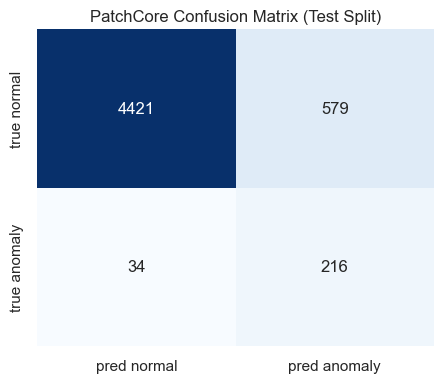

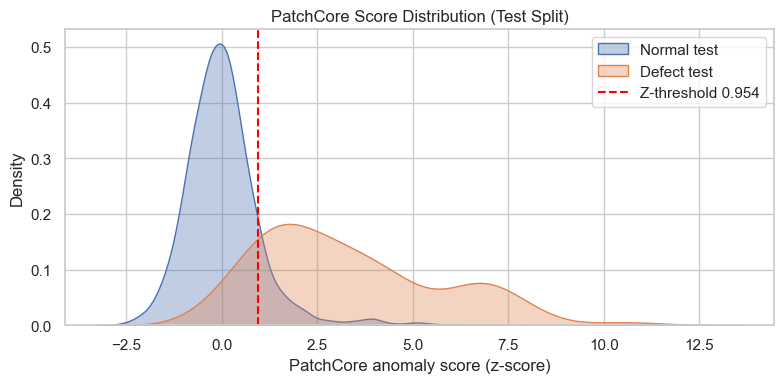

test defect samples: 250
Saved model artifact to: ../artifacts/x64/patchcore_efficientnet_b0_50k\patchcore_efficientnet_b0_model.pt
Saved metrics to: ../artifacts/x64/patchcore_efficientnet_b0_50k\evaluation_metrics.json


In [24]:
# threshold_z = 1.2
# Final evaluation on test split (kept untouched during threshold tuning)
y_true = np.concatenate([
    np.zeros(len(test_normal_scores_z), dtype=int),
    np.ones(len(test_defect_scores_z), dtype=int),
])
scores = np.concatenate([test_normal_scores_z, test_defect_scores_z])
y_pred = (scores > threshold_z).astype(int)

roc_auc = float(roc_auc_score(y_true, scores))
report = classification_report(y_true, y_pred, target_names=['normal', 'anomaly'])

print(f'ROC-AUC (z-score): {roc_auc:.4f}')
print(f'Applied z-threshold: {threshold_z:.6f} | raw-threshold: {threshold_raw:.6f}')
print(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred normal', 'pred anomaly'],
            yticklabels=['true normal', 'true anomaly'])
plt.title('PatchCore Confusion Matrix (Test Split)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.kdeplot(test_normal_scores_z, label='Normal test', fill=True, alpha=0.35)
sns.kdeplot(test_defect_scores_z, label='Defect test', fill=True, alpha=0.35)
plt.axvline(threshold_z, color='red', linestyle='--', label=f'Z-threshold {threshold_z:.3f}')
plt.xlabel('PatchCore anomaly score (z-score)')
plt.ylabel('Density')
plt.title('PatchCore Score Distribution (Test Split)')
plt.legend()
plt.tight_layout()
plt.show()
print('test defect samples:', TEST_DEFECT_N)

# Store model artifacts
artifact = {
    'extractor_state_dict': extractor.state_dict(),
    # 'memory_bank': memory_bank.detach().cpu(),
    'threshold_z': float(threshold_z),
    'threshold_raw': float(threshold_raw),
    'train_score_mu': float(train_score_mu),
    'train_score_std': float(train_score_std),
    'config': {
        'image_size': IMAGE_SIZE,
        'train_normal_n': TRAIN_NORMAL_N,
        'tune_normal_n': TUNE_NORMAL_N,
        'tune_defect_n': TUNE_DEFECT_N,
        'test_normal_n': TEST_NORMAL_N,
        'test_defect_n': TEST_DEFECT_N,
        'score_chunk': SCORE_CHUNK,
        'patchcore_nn_k': PATCHCORE_NN_K,
        'patchcore_topk_patch_ratio': TOPK_PATCH_RATIO,
        'effnet_mid_feature_idx': EFFNET_MID_FEATURE_IDX,
        'effnet_deep_feature_idx': EFFNET_DEEP_FEATURE_IDX,
        'patch_embed_dim': PATCH_EMBED_DIM,
    },
}
torch.save(artifact, MODEL_EXPORT_PATH)

metrics = {
    'roc_auc_z': roc_auc,
    'threshold_z': float(threshold_z),
    'threshold_raw': float(threshold_raw),
    'train_score_mu': float(train_score_mu),
    'train_score_std': float(train_score_std),
    'confusion_matrix': cm.tolist(),
    'n_test_normal': int(len(test_normal_scores_z)),
    'n_test_defect': int(len(test_defect_scores_z)),
}
pd.Series(metrics).to_json(METRICS_EXPORT_PATH, indent=2)

print('Saved model artifact to:', MODEL_EXPORT_PATH)
print('Saved metrics to:', METRICS_EXPORT_PATH)




In [25]:
#print out each defected wafer's score and label for manual inspection
# Per-class breakdown
tmp = test_defect_df.copy()
tmp['score']    = test_defect_scores_z
tmp['detected'] = (test_defect_scores_z > threshold_z).astype(int)
print('\nPer-defect-class recall:')
display(tmp.groupby('failure_label').agg(
    count=('detected','count'), detected=('detected','sum'),
    recall=('detected','mean'), mean_score=('score','mean'),
).round(3).sort_values('recall'))
    


Per-defect-class recall:


,count,detected,recall,mean_score
failure_label,,,,
Center,45,27,0.600,1.209
Scratch,12,8,0.667,3.040
Loc,36,30,0.833,2.430
Edge-Loc,48,42,0.875,2.973
Donut,6,6,1.000,3.527
Edge-Ring,93,93,1.000,4.526
Near-full,1,1,1.000,8.037
Random,9,9,1.000,6.268


In [26]:
# Clear memory after run
vars_to_clear = [
    'train_dataset', 'test_normal_dataset', 'test_defect_dataset',
    'sample_x', 'sample_y',
    'sampled_patches', 'memory_bank', 'memory_bank_t',
    'train_scores', 'tune_normal_scores', 'tune_defect_scores',
    'test_normal_scores', 'test_defect_scores',
    'train_scores_z', 'tune_normal_scores_z', 'tune_defect_scores_z',
    'test_normal_scores_z', 'test_defect_scores_z',
    'scores', 'y_true', 'y_pred',
    'train_loader', 'tune_normal_loader', 'tune_defect_loader',
    'test_normal_loader', 'test_defect_loader',
]
for name in vars_to_clear:
    if name in globals():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print('Memory cleared (Python GC + CUDA cache).')

Memory cleared (Python GC + CUDA cache).


## Notes

- Memory bank is capped by `MEMORY_BANK_MAX_PATCHES` to control RAM/VRAM.
- If GPU memory is tight, reduce `BATCH_SIZE` and/or `SCORE_CHUNK`.
- You can tune threshold percentile for precision/recall tradeoff (e.g., 98.5 to 99.5).